# 06 The Pipeline

**How do the individual analyses become something that can be used in practice?**

## Where the pipeline is

**Notebooks 01 to 05, run in sequence, form the pipeline.** Each notebook reads the output of the previous one, so a new survey dataset enters at Notebook 01 and emerges here with all derived measures attached.

There is no separate implementation. Keeping the analytical notebooks and the operational pipeline identical avoids maintaining two versions of the same logic.

What runs, and what it costs:

| | Stage | Winning model | Decided in | Cost |
| :-- | :--- | :--- | :--- | :--- |
| 01 | clean | — | — | seconds |
| 02 | **valence** | Gemma 2 9B, judging blind | notebook 02 | ~5 s per comment |
| 03 | **arousal** | IMS lexicon mean, stopwords removed | notebook 03 | seconds |
| 03 | *(also run)* | LLM arousal — rejected, carried along | notebook 03 | ~2 s per comment |
| 05 | **topics** | BERTopic, fitted fresh, labelled locally | notebook 05 | minutes |
| 06 | assemble | — | — | seconds |

This notebook performs the final step: assembling the outputs into a dashboard-ready model and exporting the files required by Power BI.

## Why a star schema and not one wide table

A single table with one row per respondent and every attribute attached would be the simplest export, but not the most efficient one. Topic labels, area names, and other descriptive information would be repeated thousands of times, increasing model size and slowing dashboard interactions.

Instead, the data are organised as a star schema: a central fact table surrounded by smaller dimension tables. This structure reduces redundancy, keeps relationships explicit, and supports fast filtering and aggregation in Power BI.

Each topic label, area name, or lookup value exists only once, while the fact table contains the observations to be analysed.

In [1]:
# ============================================================
# Imports
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

DATA = Path("../synthetic_dataset")

# ---- which dataset ----------------------------------------------------------
SOURCE = "synthetic"

if SOURCE == "synthetic":
    WORK = DATA / "synthetic"
elif SOURCE == "real":
    WORK = DATA / "results" / "real_run"
    WORK.mkdir(parents=True, exist_ok=True)
    print("!" * 70)
    print("SOURCE = 'real'. The dashboard files this run writes contain real employee")
    print("comments. Keep them out of any shared workspace, and do not share the")
    print("executed copy of this notebook.")
    print("!" * 70 + "\n")
else:
    raise ValueError("SOURCE must be 'synthetic' or 'real'")

INPUT = WORK / f"{SOURCE}_topics_engagement.parquet"
OUT_DIR = WORK / f"dashboard_{SOURCE}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_CELL = 5          # groups smaller than this are flagged, not removed

data = pd.read_parquet(INPUT)
print(f"{len(data):,} responses, {len(data.columns)} columns")
print(f"with a comment: {int(data['has_comment'].sum()):,}")

5,000 responses, 95 columns
with a comment: 2,500


## Step 1 — Did anything upstream change?

Before exporting the data model, the key results from the previous notebooks are checked once more. If any of these figures has changed materially, something upstream has changed and the export should wait until the cause is understood.

The numbers below are quality criteria rather than business findings. They describe how well the measures performed during validation and how independently the two dimensions behave. They do not describe how employees feel; they describe how trustworthy the measurements are.

These are the benchmark figures established in the earlier notebooks. They are checked again before export to ensure that the pipeline still produces the expected results.

In [2]:
# ============================================================
# Regression Check
# ============================================================

commented = data[data["has_comment"] == 1]

CRITERIA = ["arbeitsfreude", "arbeitgeber_empfehlung", "teamstimmung",
            "work_life_balance", "engagement_score", "overall_score"]

print("valence against the survey criteria (Spearman):")
values = []
for criterion in CRITERIA:
    pair = commented[["valence", criterion]].dropna()
    rho = pair["valence"].corr(pair[criterion], method="spearman")
    values.append(rho)
    print(f"  {criterion:24s} {rho:+.3f}")
print(f"  {'mean':24s} {np.mean(values):+.3f}")
print("\nFour of the six overlap — three are components of engagement_score and")
print("overall_score averages over everything. Three criterion groups, not six.")

axes = commented[["valence", "arousal"]].dropna()
independence = axes["valence"].corr(axes["arousal"], method="spearman")
print(f"\nthe two axes against each other: {independence:+.3f}")
print("Near zero is required: a second axis that tracks the first carries nothing.")

for column, label in [("valence", "valence"), ("arousal", "arousal"),
                      ("topic_id", "topic")]:
    share = commented[column].notna().mean()
    print(f"{label:10s} present for {share:.0%} of the comments")

valence against the survey criteria (Spearman):


  arbeitsfreude            +0.417
  arbeitgeber_empfehlung   +0.436
  teamstimmung             +0.318
  work_life_balance        +0.303
  engagement_score         +0.427
  overall_score            +0.453
  mean                     +0.393

Four of the six overlap — three are components of engagement_score and
overall_score averages over everything. Three criterion groups, not six.

the two axes against each other: +0.012
Near zero is required: a second axis that tracks the first carries nothing.
valence    present for 100% of the comments
arousal    present for 100% of the comments
topic      present for 100% of the comments


## Step 2 — The star schema

Four dimension tables and one fact table.

`dim_ecke` is small but earns its place: it turns the four circumplex corners into a proper dimension, so a report can slice by *unpleasant and deactivated* without writing that condition into every measure.

The same principle applies to the other dimensions: values that repeat belong in a dimension table; observations belong in the fact table.

In [3]:
# ============================================================
# Dimensions
# ============================================================

dim_bereich = (data[["abteilungs_id", "bereich_clean", "bereich_ebene", "organisation"]]
               .drop_duplicates(subset="bereich_clean")
               .sort_values("bereich_clean")
               .reset_index(drop=True))
dim_bereich.insert(0, "bereich_key", np.arange(1, len(dim_bereich) + 1))

dim_iteration = (data[["iteration_id", "run_id"]].drop_duplicates()
                 .sort_values(["iteration_id", "run_id"]).reset_index(drop=True))
dim_iteration.insert(0, "iteration_key", np.arange(1, len(dim_iteration) + 1))

labels = pd.read_csv(WORK / f"{SOURCE}_topic_labels.csv", sep=";", encoding="utf-8-sig")
dim_topic = labels.rename(columns={"topic_id": "topic_key"})
if -1 not in set(dim_topic["topic_key"]):
    dim_topic = pd.concat([
        pd.DataFrame([{"topic_key": -1, "topic_label": "Ohne Thema", "keywords": ""}]),
        dim_topic], ignore_index=True)

# A density field is computed per group, and a group has to be large enough to
# carry one. Bereich is not: a thousand of them share a few thousand comments. The
# first part of bereich_ebene is the level that holds up.
dim_bereich["division"] = (dim_bereich["bereich_ebene"].astype("string")
                           .str.split("-").str[0].fillna("ohne Zuordnung"))

dim_division = (dim_bereich[["division"]].drop_duplicates()
                .sort_values("division").reset_index(drop=True))

# A corner is a quadrant of the circumplex, not an emotion. Feeling tense is one of
# many things that sit at low valence and high arousal, and naming the whole quadrant
# after it claims more than two axes can carry. The export therefore names each corner
# by its coordinates. Notebook 04 keeps the emotion words in its own picture, where a
# reader needs something concrete to hold on to.
ECKEN = {
    "begeistert / energiegeladen": ("High Valence/High Arousal", "angenehm", "hoch"),
    "angespannt / nervös": ("Low Valence/High Arousal", "unangenehm", "hoch"),
    "erschöpft / resigniert": ("Low Valence/Low Arousal", "unangenehm", "niedrig"),
    "gelassen / entspannt": ("High Valence/Low Arousal", "angenehm", "niedrig"),
}

dim_ecke = pd.DataFrame(
    [{"corner": ecke, "valenz": valenz, "aktivierung": aktivierung}
     for ecke, valenz, aktivierung in ECKEN.values()])

for name, table in [("dim_bereich", dim_bereich), ("dim_iteration", dim_iteration),
                    ("dim_topic", dim_topic), ("dim_ecke", dim_ecke),
                    ("dim_division", dim_division)]:
    print(f"  {name:14s} {len(table):5,} rows, {len(table.columns)} columns")

  dim_bereich       12 rows, 5 columns
  dim_iteration     14 rows, 3 columns
  dim_topic         35 rows, 3 columns
  dim_ecke           4 rows, 3 columns


In [4]:
# ============================================================
# Fact Table
# ============================================================

JITTER = 0.025        # half the grid step of the valence score, as in notebook 04
JITTER_SEED = 42      # fixed: the dashboard must not shift between runs
HEAT_BINS = 20        # resolution of the circumplex raster the dashboard draws

fact = data.merge(dim_bereich[["bereich_key", "bereich_clean"]],
                  on="bereich_clean", how="left")
fact = fact.merge(dim_iteration, on=["iteration_id", "run_id"], how="left")
fact = fact.rename(columns={"topic_id": "topic_key"})

SCORES = [c for c in data.columns if c.endswith("_score")]
COLUMNS = (["id", "bereich_key", "iteration_key", "start", "ende", "duration_minutes",
            "has_comment", "freitext_kommentar", "word_count", "length",
            "valence", "valence_rank", "arousal", "arousal_raw", "corner", "topic_key",
            "arousal_llm_rejected", "n_no_judgement", "answer_std",
            "flag_speeder", "flag_straightliner", "quality_flag"] + SCORES)
fact = fact[[c for c in COLUMNS if c in fact.columns]]

# The corner is the key of dim_ecke, so it has to be renamed here as well or the
# relationship finds nothing. Anything that is neither blank nor one of the four
# is a change upstream that this export has not been told about.
fremd = set(fact["corner"].dropna()) - set(ECKEN)
if fremd:
    raise ValueError(f"corner values without a quadrant: {sorted(fremd)}")
fact["corner"] = fact["corner"].map({emotion: ecke for emotion, (ecke, *_) in ECKEN.items()})

# Free text plus a small department can identify a person. The flag exists to be
# filtered on; removing rows is a decision for whoever publishes the dashboard.
sizes = fact.groupby(["bereich_key", "iteration_key"])["id"].transform("size")
fact["group_small"] = (sizes < MIN_CELL).astype(int)

# The language model puts nearly all its probability on round numbers, so valence
# arrives in steps of 0.05. Drawn as it is, the circumplex becomes a comb of
# vertical stripes — an artefact of the measurement rather than a property of the
# comments. Notebook 04 undoes the rounding before it estimates the density, and
# the correction has to travel with the export: Power BI cannot spread a value
# across the interval it stands for at query time.
rng = np.random.default_rng(JITTER_SEED)
placed = fact["valence"].notna() & fact["arousal"].notna()
jittered = (fact["valence"] + rng.uniform(-JITTER, JITTER, len(fact))).clip(-1, 1)
fact["valence_jitter"] = jittered.where(placed)

# Both axes as grid cells, each labelled with its lower edge so the bins sort as
# numbers rather than as text. This is what the heatmap is built from: arousal on
# the rows, valence on the columns, a count of comments in between.
step = 2 / HEAT_BINS
for column, source in [("valence_bin", "valence_jitter"), ("arousal_bin", "arousal")]:
    edge = np.floor((fact[source] + 1) / step).clip(0, HEAT_BINS - 1) * step - 1
    fact[column] = edge.where(placed).round(3)

TABLES = {"fact_antworten": fact, "dim_bereich": dim_bereich,
          "dim_iteration": dim_iteration, "dim_topic": dim_topic,
          "dim_ecke": dim_ecke, "dim_division": dim_division}

for name, table in TABLES.items():
    path = OUT_DIR / f"{name}.csv"
    table.to_csv(path, index=False, sep=";", encoding="utf-8-sig", decimal=",")
    print(f"  {name:16s} {len(table):6,} rows   {path.stat().st_size / 1e6:5.2f} MB")

print(f"\nrows in cells smaller than {MIN_CELL}: {int(fact['group_small'].sum()):,} "
      f"({fact['group_small'].mean():.0%}) — flagged, not removed")

print(f"\nvalence: {fact['valence'].nunique():,} distinct values before de-rounding, "
      f"{fact['valence_jitter'].nunique():,} after")
raster = fact.groupby(["arousal_bin", "valence_bin"]).size()
print(f"raster: {HEAT_BINS} x {HEAT_BINS} cells, {int(placed.sum()):,} comments placed, "
      f"{len(raster):,} cells filled, {(raster >= MIN_CELL).mean():.0%} of those "
      f"hold {MIN_CELL} or more")

  fact_antworten    5,000 rows    1.97 MB
  dim_bereich          12 rows    0.00 MB
  dim_iteration        14 rows    0.00 MB
  dim_topic            35 rows    0.01 MB
  dim_ecke              4 rows    0.00 MB

rows in cells smaller than 5: 0 (0%) — flagged, not removed


## Step 3 — The density field

The raster in the fact table counts comments per cell. It slices by anything, because
it is computed from the rows themselves, but at a useful resolution the valence axis
runs out of distinct values and the picture breaks into stripes.

A smoothed field has no such limit, and it cannot be produced in Power BI. It is
computed here instead, per division and survey iteration, and exported as its own
table.

Smoothing is a convolution, and convolution is linear, so the fields of several
groups add up to the field of those groups pooled — provided every group is smoothed
with the identical kernel. That is the one thing this step has to get right, and the
check below asserts it: any selection of divisions and iterations, summed in Power
BI, is the same picture as computing the density on exactly those comments.

What it does not do is rescue a small selection. A field over four comments is four
blurred dots that look like a distribution, which is why the export also reports how
many comments each division carries and the measures blank the field below a floor.


In [ ]:
# ============================================================
# Density Field
# ============================================================

GRID = 60             # resolution of the field, far finer than the fact raster
BANDWIDTH = 0.16      # kernel width as a share of the spread, as in notebook 04
MIN_FIELD = 50        # below this many comments a smoothed field is decoration
DECIMALS = 4          # rounding, which also drops the cells that contribute nothing

placed = fact.dropna(subset=["valence_jitter", "arousal"]).merge(
    dim_bereich[["bereich_key", "division"]], on="bereich_key", how="left")
placed["division"] = placed["division"].fillna("ohne Zuordnung")

edges = np.linspace(-1, 1, GRID + 1)
step = 2 / GRID

# One kernel for every group, its width pinned to the whole corpus. This is what
# makes the fields add up. The gaussian_kde in notebook 04 scales its bandwidth to
# each dataset's own spread, so per-group kernels would each smooth differently and
# the parts would no longer sum to the whole. Valence and arousal are close to
# independent by construction, so a kernel without a tilt is enough.
sigma = [BANDWIDTH * placed["arousal"].std() / step,
         BANDWIDTH * placed["valence_jitter"].std() / step]


def density(subset):
    """Comments per grid cell. Arousal is mirrored at the boundaries and valence
    deliberately is not — the same asymmetry notebook 04 argues for."""
    counts, _, _ = np.histogram2d(subset["arousal"], subset["valence_jitter"],
                                  bins=[edges, edges])
    return gaussian_filter(counts, sigma, mode=["reflect", "constant"])


fields = []
for (division, iteration), subset in placed.groupby(["division", "iteration_key"]):
    z = density(subset).round(DECIMALS)
    rows, columns = np.nonzero(z)
    fields.append(pd.DataFrame({
        "division": division,
        "iteration_key": iteration,
        "arousal_zelle": (rows * step - 1 + step / 2).round(4),
        "valence_zelle": (columns * step - 1 + step / 2).round(4),
        "dichte": z[rows, columns]}))
fact_dichte = pd.concat(fields, ignore_index=True)

TABLES["fact_dichte"] = fact_dichte
path = OUT_DIR / "fact_dichte.csv"
fact_dichte.to_csv(path, index=False, sep=";", encoding="utf-8-sig", decimal=",")
print(f"  fact_dichte      {len(fact_dichte):8,} rows   {path.stat().st_size / 1e6:5.2f} MB")
print(f"  {fact_dichte.groupby(['division', 'iteration_key']).ngroups:,} groups "
      f"over {placed['division'].nunique()} divisions")

# The claim the table rests on: the groups summed must reproduce the field over all
# comments. If this ever drifts, the kernel is no longer identical across groups and
# every sliced view in the dashboard is quietly wrong.
whole = density(placed)
summed = np.zeros_like(whole)
cell = {axis: ((fact_dichte[f"{axis}_zelle"] + 1 - step / 2) / step)
        .round().astype(int).to_numpy() for axis in ["arousal", "valence"]}
np.add.at(summed, (cell["arousal"], cell["valence"]),
          fact_dichte["dichte"].to_numpy())
print(f"  summed parts against the whole: "
      f"{np.abs(whole - summed).max() / whole.max():.3%} of the peak")
print(f"  mass {fact_dichte['dichte'].sum():,.0f} against {len(placed):,} comments "
      f"— the difference ran off the valence edge, which is not mirrored")

carried = placed.groupby("division").size()
print(f"\ndivisions carrying at least {MIN_FIELD} comments: "
      f"{int((carried >= MIN_FIELD).sum())} of {len(carried)}, holding "
      f"{carried[carried >= MIN_FIELD].sum() / len(placed):.0%} of the comments")

## Step 4 — What the pipeline produces

The analytical work is finished at this point. What remains is to package the results in a form that Power BI can consume reliably.

The export consists of four files:

**`dashboard.pbids`** — opens Power BI Desktop with the correct data source already configured.

**`power_query.m`** — loads all tables with the expected separators, encoding, and number formats.

**`measures.dax`** — provides the core calculations used in the reports, including suppression rules for very small respondent groups.

**`relationships.md`** — documents the relationships between the fact table and the dimensions so the model can be recreated consistently.

Together these files provide everything required to rebuild the dashboard model from the exported data.

In [5]:
# ============================================================
# Power BI Helpers
# ============================================================

folder = str(OUT_DIR)

(OUT_DIR / "dashboard.pbids").write_text(json.dumps({
    "version": "0.1",
    "connections": [{"details": {"protocol": "folder",
                                 "address": {"path": folder}}}],
}, indent=2), encoding="utf-8")

query = ["// Power BI: Daten abrufen -> Leere Abfrage -> Erweiterter Editor.",
         "// Pro Tabelle eine Abfrage anlegen und den passenden Block einfuegen.",
         f"// Ordner: {folder}", ""]
for name in TABLES:
    query.append(
        f"// ---------- {name}\n"
        "let\n"
        "    Quelle = Csv.Document(\n"
        f'        File.Contents("{folder}/{name}.csv"),\n'
        '        [Delimiter = ";", Encoding = 65001, QuoteStyle = QuoteStyle.Csv]\n'
        "    ),\n"
        "    Kopf = Table.PromoteHeaders(Quelle, [PromoteAllScalars = true]),\n"
        '    Typen = Table.TransformColumnTypes(Kopf, {}, "de-DE")\n'
        "in\n"
        "    Typen")
(OUT_DIR / "power_query.m").write_text("\n\n".join(query), encoding="utf-8")

(OUT_DIR / "relationships.md").write_text(f"""# Relationships

Each dimension joins to the fact table one-to-many, filtering in one direction.

| From | To | Cardinality |
| :--- | :--- | :--- |
| `dim_bereich[bereich_key]` | `fact_antworten[bereich_key]` | 1 : n |
| `dim_iteration[iteration_key]` | `fact_antworten[iteration_key]` | 1 : n |
| `dim_topic[topic_key]` | `fact_antworten[topic_key]` | 1 : n |
| `dim_ecke[corner]` | `fact_antworten[corner]` | 1 : n |
| `dim_division[division]` | `dim_bereich[division]` | 1 : n |
| `dim_division[division]` | `fact_dichte[division]` | 1 : n |
| `dim_iteration[iteration_key]` | `fact_dichte[iteration_key]` | 1 : n |

`dim_division` is the shared dimension: one slicer on it filters the raster and the
density field together. `dim_bereich[division]` repeats, so it cannot carry the
relationship itself.

`corner` names a quadrant by its coordinates, `Low Valence/High Arousal`, rather
than by a feeling. An emotion word would name the whole quadrant after one of the
many states that sit in it, which is more than two axes can carry. The columns
`valenz` and `aktivierung` in `dim_ecke` hold the same information split in two, for
slicing on one axis at a time.

`topic_key = -1` is the outlier group: comments BERTopic could not place. It is a
real category, not missing data, and belongs in the reports as such.

Respondents without a comment have no valence, arousal, corner or topic. That is
correct — they wrote nothing — so measures over those columns must ignore them
rather than counting them as zero.


# The circumplex raster

`valence_bin` and `arousal_bin` place each comment in a {HEAT_BINS} x {HEAT_BINS} grid
over the circumplex. Each holds the lower edge of its cell, so the bins sort as
numbers. They serve one purpose: the heatmap.

They exist because the valence score arrives rounded to steps of 0.05, which draws
as a comb of vertical stripes. `valence_jitter` spreads each score across the
interval it stands for, {JITTER} either side, and is what `valence_bin` is built
from. Use plain `valence` for every average, comparison and threshold — the
jittered column is for the picture only and carries nothing the rounded one does
not.

In Power BI: a matrix with `arousal_bin` on the rows sorted descending,
`valence_bin` on the columns, and `[Zellendichte]` as the value. Then conditional
formatting on the cell background, and the font in the background colour so the
numbers disappear.


# The density field

`fact_dichte` holds a {GRID} x {GRID} smoothed field per division and iteration:
`dichte` is comments per grid cell, `valence_zelle` and `arousal_zelle` are cell
centres. Cells that round to zero are absent rather than stored.

Aggregate it with SUM and never with AVERAGE. Summed over any selection of divisions
and iterations it reproduces the field over exactly those comments, because every
group was smoothed with the same kernel. Averaged, a division with twelve comments
would weigh as much as one with seven hundred.

It does not join to `valence_bin` and `arousal_bin`: those are a coarser grid on the
fact table and a different thing. Use the raster when the selection is small or when
filtering by Bereich or topic, and the field when it is large.
""", encoding="utf-8")

(OUT_DIR / "measures.dax").write_text(f"""// Basics

Antworten = COUNTROWS(fact_antworten)

Mit Kommentar = CALCULATE([Antworten], fact_antworten[has_comment] = 1)

Kommentarquote = DIVIDE([Mit Kommentar], [Antworten])


// Affect. AVERAGE ignores blanks, so respondents without a comment drop out by
// themselves rather than being counted as neutral.

Valenz = AVERAGE(fact_antworten[valence])

Arousal = AVERAGE(fact_antworten[arousal])

Anteil unangenehm =
DIVIDE(
    CALCULATE([Mit Kommentar], fact_antworten[valence] < 0),
    CALCULATE([Mit Kommentar], NOT ISBLANK(fact_antworten[valence]))
)

Anteil Ecke =
DIVIDE(
    CALCULATE([Mit Kommentar], NOT ISBLANK(fact_antworten[corner])),
    CALCULATE([Mit Kommentar], ALL(dim_ecke), NOT ISBLANK(fact_antworten[corner]))
)


// Circumplex heatmap. The matrix draws one square per raster cell, and a square
// nobody landed in is a real zero rather than a gap. Adding zero keeps those empty
// squares in the matrix instead of letting them drop out of it.

Zellendichte = [Mit Kommentar] + 0


// Survey scores

Engagement = AVERAGE(fact_antworten[engagement_score])

Gesamtscore = AVERAGE(fact_antworten[overall_score])


// The density field. Summed, never averaged — see relationships.md. The floor is
// the same idea as the suppression below: under {MIN_FIELD} comments a smoothed
// field shows structure that the comments behind it do not support.

Dichte = SUM(fact_dichte[dichte])

Kommentare im Feld =
CALCULATE([Antworten], NOT ISBLANK(fact_antworten[arousal_bin]))

Dichte (geprueft) =
IF([Kommentare im Feld] >= {MIN_FIELD}, [Dichte], BLANK())


// Data protection. Use these in anything shown outside the analysis team: a cell
// with fewer than five respondents returns blank instead of a value.

Antworten (geschuetzt) =
VAR Anzahl = [Antworten]
RETURN IF(Anzahl >= 5, Anzahl, BLANK())

Valenz (geschuetzt) = IF([Antworten] >= 5, [Valenz], BLANK())

Engagement (geschuetzt) = IF([Antworten] >= 5, [Engagement], BLANK())
""", encoding="utf-8")

for name in ["dashboard.pbids", "power_query.m", "measures.dax", "relationships.md"]:
    path = OUT_DIR / name
    print(f"  {name:22s} {path.stat().st_size / 1e3:6.1f} kB")
print(f"\neverything in: {folder}")

  dashboard.pbids           0.3 kB
  power_query.m             2.3 kB
  measures.dax              1.2 kB
  relationships.md          0.8 kB

everything in: ../data/synthetic/dashboard_synthetic


## Step 5 — What it looks like

Everything above is files. Before handing over, one picture of what those files contain —
the two things the dashboard is built to show, drawn straight from the fact table that was
just written.

This is a check as much as a preview: if the export is wrong, it is visible here rather
than in Power BI.

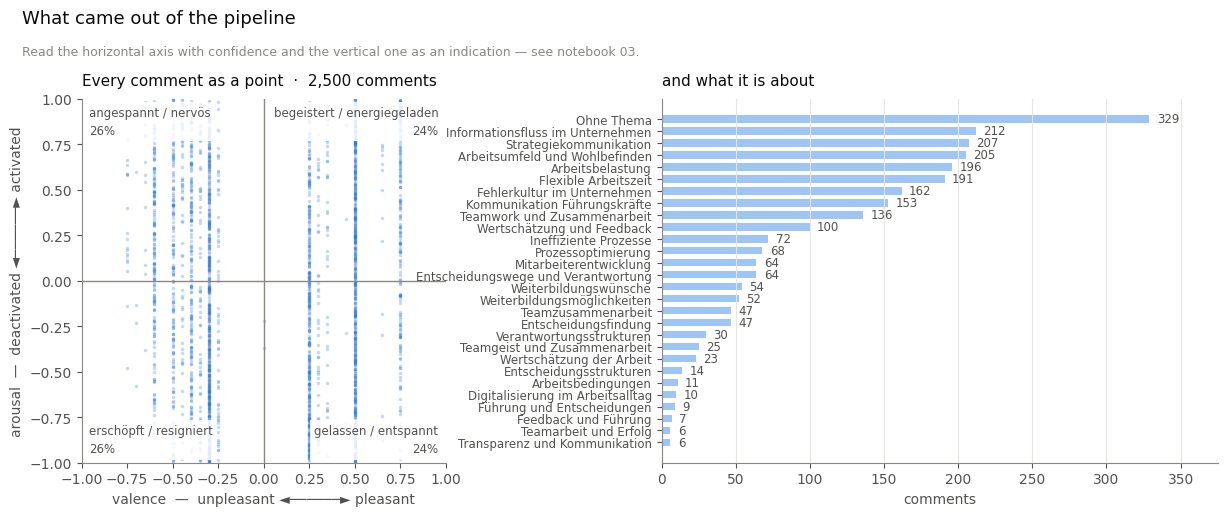

written: overview.png


In [6]:
# ============================================================
# A Look at What Was Exported
# ============================================================

import matplotlib.pyplot as plt

BLUE, BLUE_SOFT = "#2a78d6", "#9ec5f4"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "legend.frameon": False,
})

written = fact[fact["has_comment"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6),
                         gridspec_kw={"width_ratios": [1, 1.15]})
fig.subplots_adjust(left=0.06, right=0.98, top=0.78, bottom=0.13, wspace=0.30)

# --- left: the affect space, one point per comment ---------------------------
space = axes[0]
space.scatter(written["valence"], written["arousal"], s=6, color=BLUE, alpha=0.28,
              linewidths=0)
space.axvline(0, color=INK_MUTED, lw=1, zorder=3)
space.axhline(0, color=INK_MUTED, lw=1, zorder=3)

for corner, share in written["corner"].value_counts(normalize=True).items():
    # each corner label goes where its own comments sit, so the picture stays right
    # even if the corner naming changes upstream
    part = written[written["corner"] == corner]
    left = part["valence"].mean() < 0
    high = part["arousal"].mean() > 0
    space.text(-0.96 if left else 0.96, 0.96 if high else -0.96,
               f"{corner}\n{share:.0%}",
               ha="left" if left else "right", va="top" if high else "bottom",
               color=INK_SOFT, fontsize=8.5, linespacing=1.5, zorder=4,
               bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=3))

space.set_xlim(-1, 1)
space.set_ylim(-1, 1)
space.set_aspect("equal")
space.grid(False)
space.set_xlabel("valence  —  unpleasant ◄──────► pleasant")
space.set_ylabel("arousal  —  deactivated ◄──────► activated")
space.set_title(f"Every comment as a point  ·  {len(written):,} comments",
                fontsize=11, loc="left", pad=10)

# --- right: what they are about ----------------------------------------------
sizes = (written.merge(dim_topic, on="topic_key", how="left")["topic_label"]
         .value_counts().sort_values(ascending=True))
themes = axes[1]
themes.barh(np.arange(len(sizes)), sizes.to_numpy(), height=0.62, color=BLUE_SOFT)
for y, count in enumerate(sizes.to_numpy()):
    themes.text(count + sizes.max() * 0.015, y, f"{count:,}", va="center",
                color=INK_SOFT, fontsize=8.5)
themes.set_yticks(np.arange(len(sizes)))
themes.set_yticklabels([str(label)[:38] for label in sizes.index], fontsize=8.5)
themes.set_xlim(0, sizes.max() * 1.14)
themes.grid(axis="y", visible=False)
themes.set_xlabel("comments")
themes.set_title("and what it is about", fontsize=11, loc="left", pad=10)

fig.suptitle("What came out of the pipeline", fontsize=13, x=0.06, ha="left",
             y=0.94, color=INK)
fig.text(0.06, 0.875,
         "Read the horizontal axis with confidence and the vertical one as an "
         "indication — see notebook 03.",
         color=INK_MUTED, fontsize=9, va="top")

fig.savefig(OUT_DIR / "overview.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"written: {(OUT_DIR / 'overview.png').name}")

## What came out

Five CSV files organised as a star schema, plus four supporting files that load them into Power BI without having to reconstruct formats, measures, or relationships.

**How to read the result.** This guidance belongs in the dashboard itself as well as in the documentation.

**The horizontal axis is the strongest measure in the model.** Valence showed the most consistent agreement with independent survey criteria throughout the project. Comparisons along that axis, whether between departments, teams, or survey waves, can therefore be interpreted with confidence.

**The vertical axis should be read more cautiously.** The selected arousal measure remained largely independent of valence, but its external validation was weaker and the survey offered only limited criteria for evaluation. Corner shares are useful descriptive summaries; individual arousal values should not be treated as precise measurements.

**Topics belong to the corpus on which they were fitted.** They are findings, not fixed categories. A different organisation, survey wave, or population may produce a different topic structure, which is why BERTopic is fitted anew rather than loaded from a previous run.

**The rejected LLM arousal measure remains in the export.** It is retained as `arousal_llm_rejected` for transparency. The project records both successful and unsuccessful approaches so that modelling decisions remain visible and reproducible.

**Small groups are flagged rather than removed.** Whether very small respondent groups should appear in reports is a governance and data-protection decision. The exported measures support either approach.

---

### Running this on the real survey

The real survey is not run from this folder. It has its own copy of the six notebooks,
because the confidential branch has to stay separate from the one that is shared. The
method is identical; two things differ in practice:

**The valence stage is the expensive one** — roughly five seconds per comment, and
it is the only stage that costs hours. It writes a checkpoint after each comment, so
it can be interrupted.

**The outputs become confidential.** The dashboard files contain real comments, and
so does the executed copy of every notebook that displays them. Every notebook carries a
`SOURCE` switch and the copies in that branch have it set to `"real"`, which makes them
print a warning on the first cell — but the discipline is the person's, not the code's.